# BÀI THỰC HÀNH LAB 03: NGỮ PHÁP ĐỒ HỌA & THAO TÁC DỮ LIỆU THEO NHÓM
## Môn học: Xác suất Thống kê (UET.MAT1052)
### Môi trường: Python 3, Pandas, Seaborn & Matplotlib

---
**Họ và tên sinh viên:** .....................................................  
**Mã số sinh viên (MSV):** .....................................................  
**Lớp học phần:** .....................................................  

> **Hướng dẫn:** Chạy các ô code bằng tổ hợp phím `Shift + Enter`. Hoàn thành các ô có chú thích `# TODO:` và phân tích nhận xét kết quả thu được.

### 1. Khởi động môi trường và thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cấu hình phong cách hiển thị biểu đồ
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['font.sans-serif'] = 'Liberation Sans'
plt.rcParams['axes.unicode_minus'] = False

### 2. Khám phá dữ liệu Số ca sinh nở tại Hoa Kỳ (`us_births.csv`)
1. Đọc dữ liệu từ file `du-lieu/us_births.csv`.
2. Tính tổng số ca sinh theo từng năm và so sánh giữa biểu đồ Điểm (Scatter) và Đường (Line).

Kích thước bảng: (4018, 6)


,year,month,date_of_month,day_of_week,day_of_year,births
0,1978,1,1,7,1,4535
1,1978,1,2,1,2,9285
2,1978,1,3,2,3,9526
3,1978,1,4,3,4,9484
4,1978,1,5,4,5,9268


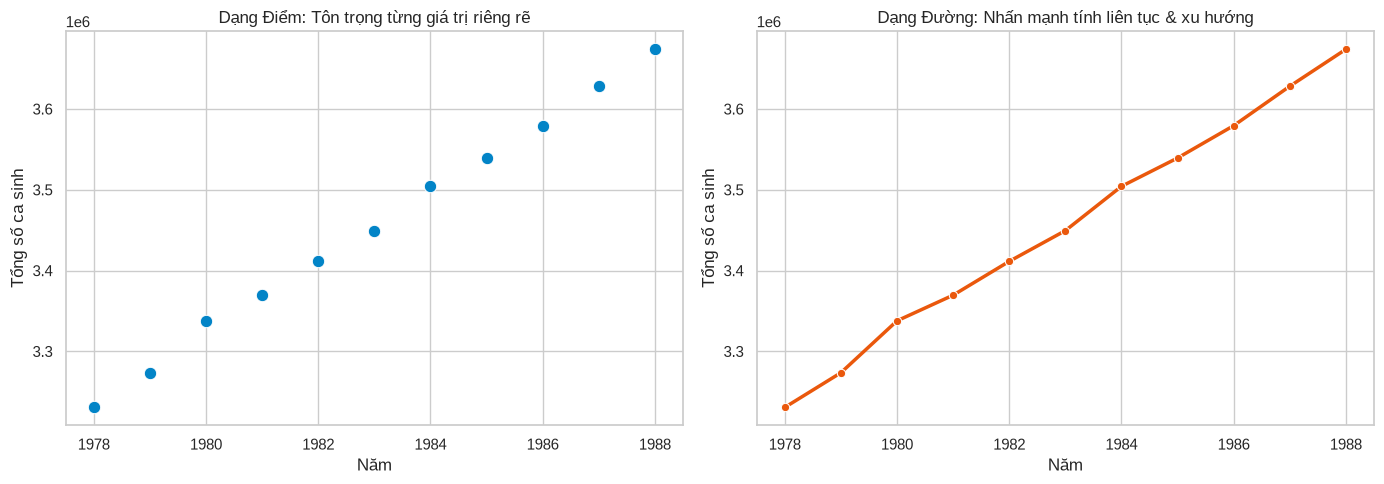

In [2]:
df_births = pd.read_csv("du-lieu/us_births.csv")
print("Kích thước bảng:", df_births.shape)
display(df_births.head())

# Tổng số ca sinh theo năm
yearly_births = df_births.groupby("year")["births"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=yearly_births, x="year", y="births", color="#0284c7", s=80, ax=axes[0])
axes[0].set(title="Dạng Điểm: Tôn trọng từng giá trị riêng rẽ", xlabel="Năm", ylabel="Tổng số ca sinh")

sns.lineplot(data=yearly_births, x="year", y="births", color="#ea580c", linewidth=2.5, marker="o", ax=axes[1])
axes[1].set(title="Dạng Đường: Nhấn mạnh tính liên tục & xu hướng", xlabel="Năm", ylabel="Tổng số ca sinh")
plt.tight_layout()
plt.show()

### 3. Giải mã hai dải dữ liệu song song (Năm 1988)
Thêm ánh xạ màu sắc theo biến phân loại ngày trong tuần vs ngày cuối tuần.

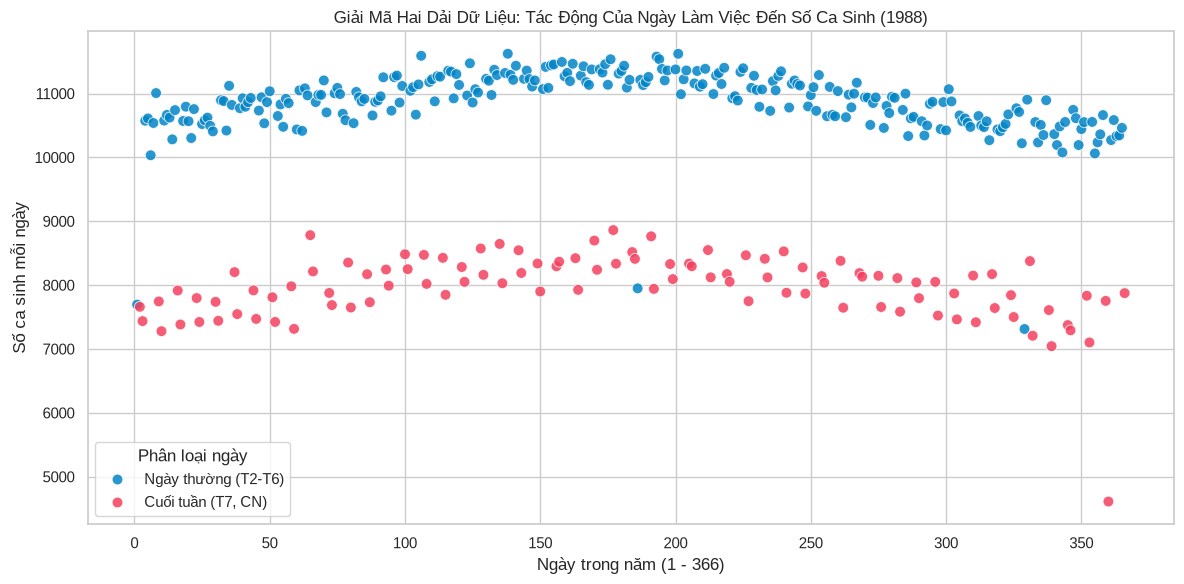

In [3]:
births_1988 = df_births.query("year == 1988").copy()
births_1988["nhom_ngay"] = births_1988["day_of_week"].apply(
    lambda x: "Cuối tuần (T7, CN)" if x in [6, 7] else "Ngày thường (T2-T6)"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=births_1988,
    x="day_of_year",
    y="births",
    hue="nhom_ngay",
    palette={"Ngày thường (T2-T6)": "#0284c7", "Cuối tuần (T7, CN)": "#f43f5e"},
    alpha=0.85,
    s=60,
    ax=ax
)
ax.set(
    title="Giải Mã Hai Dải Dữ Liệu: Tác Động Của Ngày Làm Việc Đến Số Ca Sinh (1988)",
    xlabel="Ngày trong năm (1 - 366)",
    ylabel="Số ca sinh mỗi ngày"
)
ax.legend(title="Phân loại ngày")
plt.tight_layout()
plt.show()

### 4. Ngữ pháp đồ họa đa biến trên chim cánh cụt (`penguins.csv`)
Phân biệt giữa Mapping (`hue='species'`) và Setting (`alpha=0.85`, `s=70`).

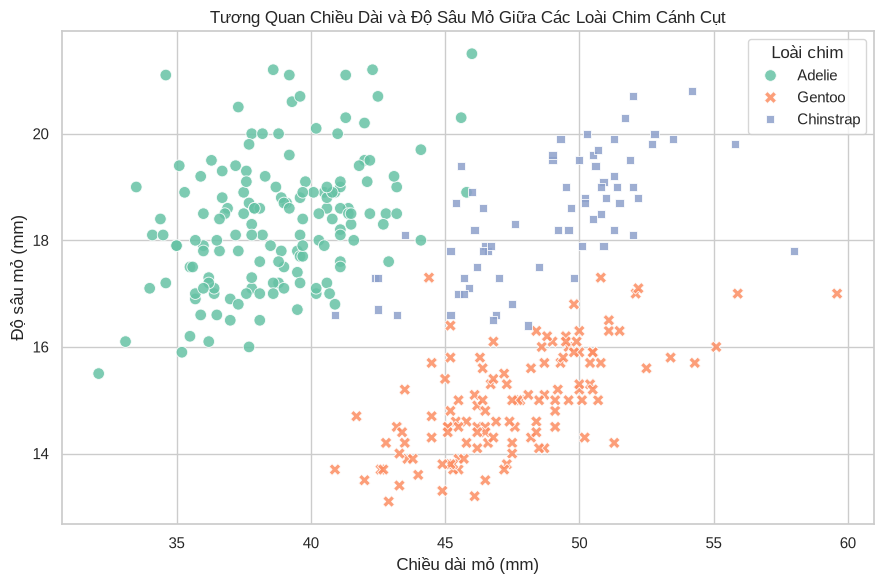

In [4]:
df_penguins = pd.read_csv("du-lieu/penguins.csv").dropna(subset=["bill_length_mm", "bill_depth_mm", "species"])

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
    s=70,
    alpha=0.85,
    palette="Set2",
    ax=ax
)
ax.set(
    title="Tương Quan Chiều Dài và Độ Sâu Mỏ Giữa Các Loài Chim Cánh Cụt",
    xlabel="Chiều dài mỏ (mm)",
    ylabel="Độ sâu mỏ (mm)"
)
ax.legend(title="Loài chim")
plt.tight_layout()
plt.show()

### 5. Dây chuyền `groupby` và kiểm tra chéo
Tính các đặc trưng trung bình và độ lệch chuẩn của các loài chim cánh cụt.

In [5]:
penguins_stats = (
    df_penguins
    .groupby("species", observed=True)
    .agg(
        so_luong=("species", "count"),
        tb_chieu_dai=("bill_length_mm", "mean"),
        do_lech_dai=("bill_length_mm", "std"),
        tb_do_sau=("bill_depth_mm", "mean"),
        do_lech_sau=("bill_depth_mm", "std")
    )
    .reset_index()
)
display(penguins_stats.round(2))

,species,so_luong,tb_chieu_dai,do_lech_dai,tb_do_sau,do_lech_sau
0,Adelie,151,38.79,2.66,18.35,1.22
1,Chinstrap,68,48.83,3.34,18.42,1.14
2,Gentoo,123,47.50,3.08,14.98,0.98


### 6. Thực nghiệm kiểm chứng Nghịch lý Simpson
So sánh tỷ lệ cá thể có khối lượng vượt 4000g: Tóm tắt gộp ($50.3\%$) vs Tóm tắt có điều kiện theo loài.

Tỷ lệ gộp toàn bộ cá thể > 4000g: 50.3%


,species,so_ca_tren_4000,tong_so,ty_le,ty_le_phan_tram
0,Adelie,35,151,0.231788,23.2
1,Chinstrap,15,68,0.220588,22.1
2,Gentoo,122,123,0.991870,99.2


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5152\628808942.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ty_le_theo_loai, x="species", y="ty_le_phan_tram", palette=["#94a3b8", "#94a3b8", "#10b981"], ax=ax)


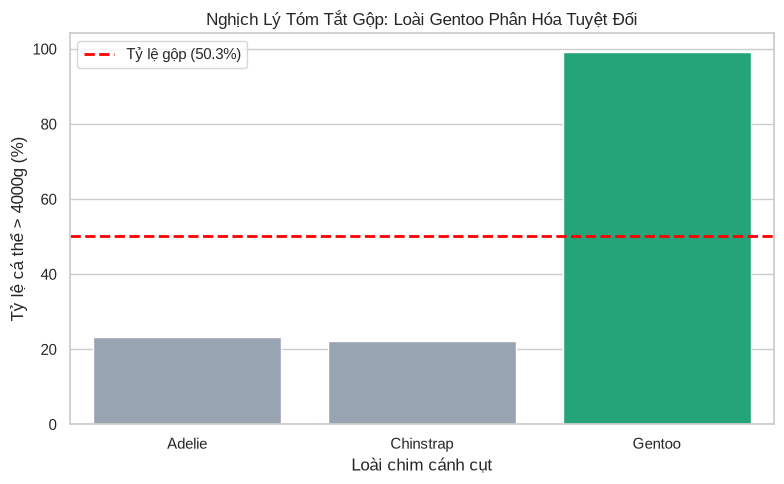

In [6]:
df_valid_mass = df_penguins.dropna(subset=["body_mass_g"]).copy()
df_valid_mass["tren_4000g"] = df_valid_mass["body_mass_g"] > 4000

ty_le_gop = df_valid_mass["tren_4000g"].mean()
print(f"Tỷ lệ gộp toàn bộ cá thể > 4000g: {ty_le_gop * 100:.1f}%")

ty_le_theo_loai = (
    df_valid_mass
    .groupby("species")["tren_4000g"]
    .agg(
        so_ca_tren_4000="sum",
        tong_so="count",
        ty_le="mean"
    )
    .reset_index()
)
ty_le_theo_loai["ty_le_phan_tram"] = (ty_le_theo_loai["ty_le"] * 100).round(1)
display(ty_le_theo_loai)

# Trực quan hóa so sánh
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ty_le_theo_loai, x="species", y="ty_le_phan_tram", palette=["#94a3b8", "#94a3b8", "#10b981"], ax=ax)
ax.axhline(ty_le_gop * 100, color="red", linestyle="--", linewidth=2, label=f"Tỷ lệ gộp ({ty_le_gop*100:.1f}%)")
ax.set(title="Nghịch Lý Tóm Tắt Gộp: Loài Gentoo Phân Hóa Tuyệt Đối", xlabel="Loài chim cánh cụt", ylabel="Tỷ lệ cá thể > 4000g (%)")
ax.legend()
plt.tight_layout()
plt.show()